# Assign 850hPa wind field to an Australian Synoptic Weather Type (SWT)

Import the data to requiring SWT assignment

In [1]:
SWTpath='/home/565/mb0427/gdata-gb02/Australian_synoptic_weather_types/'

import xarray as xr
import pickle
import numpy as np
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature, LAND

sys.path.append(SWTpath)
from assign.assign import assign_grid_to_SWT

inpath=SWTpath+'example_data/'
ufn=inpath+'20250204120000-24h-enfo-ef_u_850_0.grib2'
u=xr.open_dataset(ufn,engine='cfgrib',backend_kwargs={'indexpath': ''}, decode_timedelta=True)

vfn=inpath+'20250204120000-24h-enfo-ef_v_850_0.grib2'
v=xr.open_dataset(vfn,engine='cfgrib',backend_kwargs={'indexpath': ''}, decode_timedelta=True)


Assign the fields to a SWT name using the "assign_grid_to_SWT" function

In [11]:
u.sel(longitude=100)

<xarray.Dataset> Size: 9kB
Dimensions:        (latitude: 721)
Coordinates:
    number         int64 8B ...
    time           datetime64[ns] 8B ...
    step           timedelta64[ns] 8B ...
    isobaricInhPa  float64 8B ...
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    longitude      float64 8B 100.0
    valid_time     datetime64[ns] 8B ...
Data variables:
    u              (latitude) float32 3kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-29T15:04 GRIB to CDM+CF via cfgrib-0.9.1...

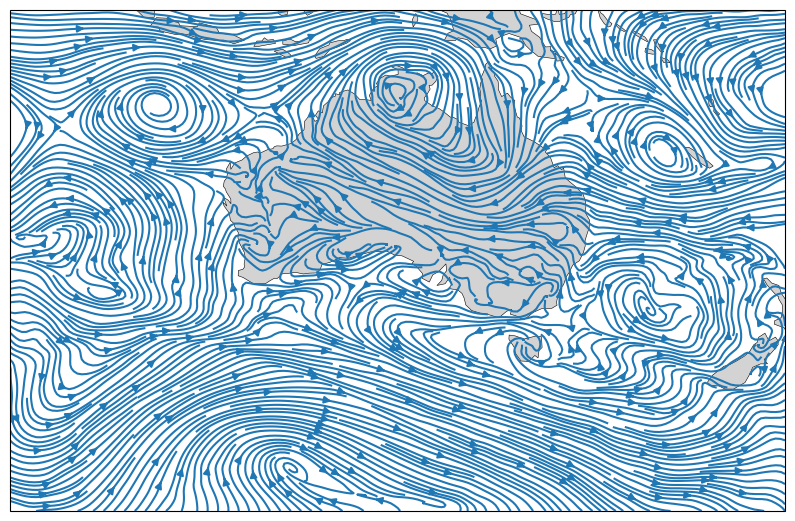

In [31]:
u1=u.reindex(latitude=list(reversed(u.latitude))).sel(longitude=slice(80,180),latitude=slice(-65,0))
v1=v.reindex(latitude=list(reversed(v.latitude))).sel(longitude=slice(80,180),latitude=slice(-65,0))

fig, ax = plt.subplots(1, 1, figsize=(10,8), subplot_kw=dict(projection=ccrs.PlateCarree())) 
plot_extent=[90,175,-60,-5]
ax.set_extent(plot_extent,crs=ccrs.PlateCarree())
ax.streamplot(u1.longitude.values,u1.latitude.values,
               u1.u.values,
               v1.v.values, density=5)
ax.add_feature(LAND,facecolor='lightgrey')
ax.coastlines(linewidths=0.4)

plt.show()

In [33]:
SWT=assign_grid_to_SWT(u.u,v.v,latname="latitude",
                       lonname="longitude",
                       cluster_filename=SWTpath+"SWT_fields/SWT_data.nc",
                       quiet=False)

Synoptic Weather Type: AM-D


Printing "assign_grid_to_SWT" function to show its usage and inputs

In [7]:
print(assign_grid_to_SWT.__doc__)

 Assign a 850hPa wind field to a Australian Synoptic Weather Type
     
    Created by Frans Liqui Lung (Monash University) and Michael A. Barnes (ARC CoE 21st Century Weather, Monash University)
    
    Parameters
    ----------
    
    u : xr.DataArray with shape (latitude,longitude) and dtype float64
        The 850hPa zonal wind field.
    v : xr.DataArray with shape (latitude,longitude) and dtype float64
        The 850hPa meridional wind field.
    
    Options
    -------
    
    latname : str (default: "latitude")
        Name of the latitude variable name in the input u and v DataArrays
    lonname : str (default: "longitude")
        Name of the longitude variable name in the input u and v DataArrays
    cluster_filename : str (default: "SWT_fields/SWT_data.nc")
        Location of the netcdf containing the clustered SWT fields.
    interpolate : bool (default: True)
        If false, does not do any interpolation on the grid. Note: if false, grids must be exactly the same